# 02. Transient Single Trajectory

This notebook mirrors the synthetic transient case from the SparseSensing transient test. There is one trajectory, eight time steps, and twenty spatial points, so the transient already has the `(time, space)` matrix shape that SSPOR expects in snapshot mode.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pysensors as ps

In [2]:
NX = 20
NT = 8
alpha = 0.5
omega = 2.0 * np.pi
X = np.linspace(0.0, 1.0, NX)
times = np.linspace(0.0, 1.0, NT)

T = (
    np.exp(-alpha * times[:, None]) * np.sin(3.0 * np.pi * X)[None, :]
    + np.cos(omega * times[:, None]) * np.sin(6.0 * np.pi * X)[None, :]
)

print(f"transient field shape: {T.shape}")

transient field shape: (8, 20)


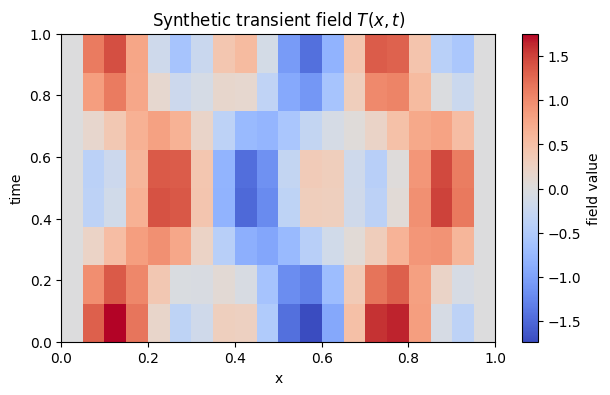

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(T, aspect="auto", origin="lower", extent=[X.min(), X.max(), times.min(), times.max()], cmap="coolwarm")
ax.set_xlabel("x")
ax.set_ylabel("time")
ax.set_title("Synthetic transient field $T(x, t)$")
fig.colorbar(im, ax=ax, label="field value")
plt.show()

In snapshot mode each time slice is treated as one row of the fit matrix. For this manufactured case no extra reshaping is needed: `mat = T` already has rows as snapshots and columns as spatial locations.

In [4]:
mat = T
model = ps.SSPOR(basis=ps.basis.SVD(n_basis_modes=3), n_sensors=3)
model.fit(mat, seed=42)
idx = model.get_selected_sensors()

print("selected sensor indices:", idx)
print("selected x-locations:", X[idx])

selected sensor indices: [11  2 17]
selected x-locations: [0.57894737 0.10526316 0.89473684]


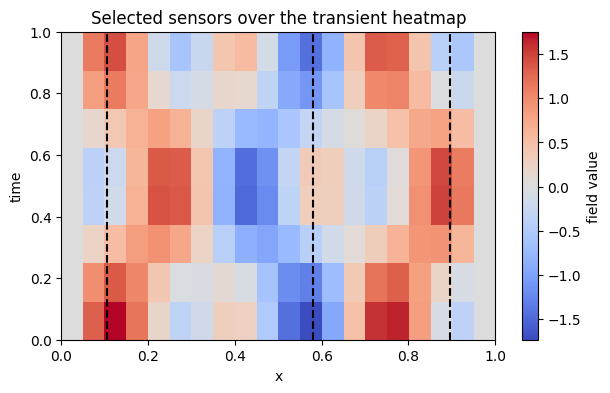

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(T, aspect="auto", origin="lower", extent=[X.min(), X.max(), times.min(), times.max()], cmap="coolwarm")

for x_sensor in X[idx]:
    ax.axvline(x_sensor, color="black", linestyle="--", linewidth=1.5)

ax.set_xlabel("x")
ax.set_ylabel("time")
ax.set_title("Selected sensors over the transient heatmap")
fig.colorbar(im, ax=ax, label="field value")
plt.show()

/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(


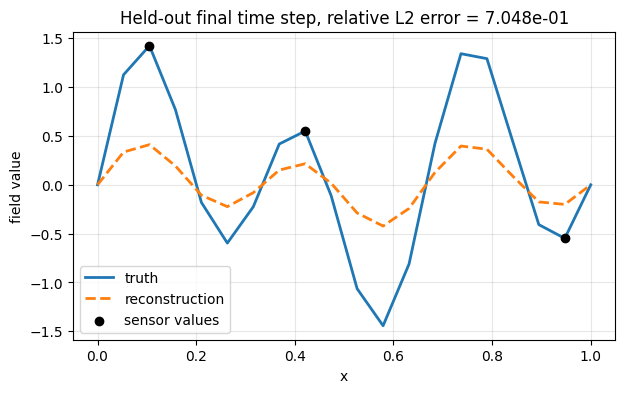

np.float64(0.7048042423536123)

In [6]:
train = T[:-1]
truth = T[-1]

heldout_model = ps.SSPOR(basis=ps.basis.SVD(n_basis_modes=3), n_sensors=3)
heldout_model.fit(train, seed=42)
heldout_idx = heldout_model.get_selected_sensors()
reconstructed = heldout_model.predict(truth[heldout_idx][None, :])[0]
relative_error = np.linalg.norm(truth - reconstructed) / np.linalg.norm(truth)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X, truth, label="truth", linewidth=2)
ax.plot(X, reconstructed, "--", label="reconstruction", linewidth=2)
ax.scatter(X[heldout_idx], truth[heldout_idx], color="black", zorder=3, label="sensor values")
ax.set_xlabel("x")
ax.set_ylabel("field value")
ax.set_title(f"Held-out final time step, relative L2 error = {relative_error:.3e}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

relative_error

The transient case shows the core reshape idea: time steps become snapshots. The next notebook adds a parameter sweep, so the fit matrix stacks both parameter and time snapshots together.